# Overfitting et underfitting

Deux maladies classiques des modèles de machine learning — et probablement les **concepts les plus importants** à maîtriser quand on débute.

> **L'analogie de l'étudiant qui révise :**
>
> - **Underfitting (sous-apprentissage)** : un étudiant qui n'a pas assez révisé. Il rate son contrôle, mais il raterait aussi n'importe quel autre exercice similaire. Son modèle du cours est *trop simple* pour capturer ce qu'il faut retenir.
>
> - **Bon apprentissage** : un étudiant qui a compris les **principes** du cours. Il réussit son contrôle et s'en sortirait aussi sur des exercices un peu différents. Il a **généralisé**.
>
> - **Overfitting (sur-apprentissage)** : un étudiant qui a appris **par cœur** les exercices du livre, y compris les fautes de frappe. Il a 20/20 sur ces exercices précis, mais s'effondre dès qu'on change une seule donnée. Il a mémorisé, pas compris.
>
> **L'objectif du ML, c'est de produire le 2e étudiant : un modèle qui *généralise*, pas qui *mémorise*.**

Dans ce notebook, on va :
1. Voir **concrètement** ce qui se passe quand on laisse un arbre de décision overfitter ;
2. Voir ce qui se passe quand on le brid trop (underfitting) ;
3. Comprendre le **compromis biais-variance** qui est derrière tout ça.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [2]:
from sklearn.datasets import load_iris
iris = load_iris()

In [3]:
X = iris.data[:, 2:] # petal length et petal width
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=2)

## Overfitting (sur-apprentissage)

**Le symptôme à reconnaître :** un modèle qui obtient un **score très élevé sur le train** (parfois parfait) mais un **score nettement plus faible sur le test**. L'écart train/test est le **signal d'alarme**.

On va le provoquer volontairement en laissant un `DecisionTreeClassifier` grandir sans **aucune limite de profondeur**. L'arbre pourra alors créer autant de branches que nécessaire pour mémoriser *chaque* exemple du jeu d'entraînement — y compris le bruit.

In [4]:
tree_over_clf = DecisionTreeClassifier(random_state=2)
tree_over_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=2)

### Structure de l'arbre

Observez la complexité de l'arbre ci-dessous (beaucoup de nœuds, beaucoup de feuilles avec très peu d'échantillons chacune). Comparez-la avec la structure de l'arbre à `max_depth = 2` vue dans [`04-understand-decision-tree`](./04-understand-decision-tree.ipynb).

Un arbre trop profond, c'est littéralement un arbre qui a créé des règles du genre *« si petal_length entre 4,85 et 4,95 et petal_width > 1,65 alors virginica »* — c'est-à-dire des **règles sur-mesure pour 1 ou 2 fleurs du jeu de train**, qui n'ont aucun sens général. C'est ça, mémoriser au lieu de comprendre.

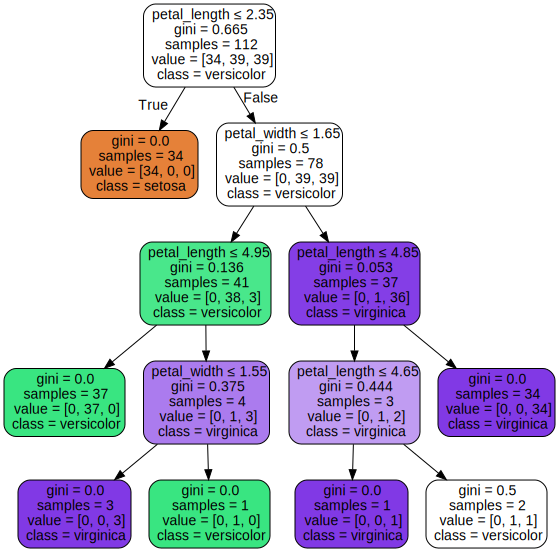

In [5]:
from sklearn.tree import export_graphviz
from graphviz import Source

dot_data = export_graphviz(tree_over_clf, out_file=None, 
                           feature_names=["petal_length", "petal_width"],  
                           class_names=iris.target_names,  
                           filled=True, rounded=True,  
                           special_characters=True)
Source(dot_data)

### Justesse de la prédiction (accuracy)

Pour évaluer les résultats du modèle on utilise la fonction `score`, qui donne l'**accuracy** : le pourcentage de prédictions correctes.

$
\text{accuracy} = \frac{\text{nombre de bonnes prédictions}}{\text{nombre total de prédictions}}
$

**Pour détecter l'overfitting, le réflexe est de comparer deux scores :**
- `score(X_train, y_train)` → ce que le modèle obtient sur **les données qu'il a vues**.
- `score(X_test, y_test)` → ce qu'il obtient sur **les données qu'il n'a jamais vues**.

**Règle de lecture :**
- Si train ≈ test, et les deux sont bons → 🎉 bonne généralisation.
- Si train ≈ test, mais les deux sont faibles → 😓 **underfitting** (modèle trop simple).
- Si train >> test → 🚨 **overfitting** (modèle qui mémorise au lieu de généraliser).

#### Rappel: modèle avec `max_depth = 3`

In [6]:
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=2)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=2)

In [7]:
tree_clf.score(X_train, y_train)

0.9821428571428571

In [8]:
tree_clf.score(X_test, y_test)

0.9736842105263158

#### Modèle sans limite de profondeur (l'arbre peut grandir autant qu'il veut)

Le `DecisionTreeClassifier` créé plus haut ne passe aucun hyperparamètre, donc scikit-learn laisse l'arbre grandir jusqu'à ce que chaque feuille soit **parfaitement pure** (ou presque). C'est le terrain de jeu rêvé pour l'overfitting.

In [9]:
tree_over_clf.score(X_train, y_train)

0.9910714285714286

In [10]:
tree_over_clf.score(X_test, y_test)

0.9210526315789473

### Diagnostic : overfitting confirmé

> **Overfitting** : sur-adaptation du modèle au jeu d'apprentissage, **aux dépens de sa capacité de généralisation**.

Observez les chiffres :
- `train` : **99,1%** — quasi parfait, l'arbre a mémorisé le jeu d'entraînement.
- `test` : **92,1%** — nettement moins bon que le modèle `max_depth=3` qui, lui, était à 97,4% sur le test.

L'arbre profond est *meilleur sur le train* mais *moins bon sur le test* que l'arbre limité. Il a gagné 1 point sur le train et **perdu 5 points sur le test** — c'est une très mauvaise affaire !

**Moralité :** limiter la profondeur de l'arbre (`max_depth=3`) a restreint sa capacité à s'adapter au jeu d'apprentissage, **au bénéfice** de sa capacité à généraliser à de nouveaux cas. C'est ce qu'on appelle **régulariser** le modèle.

## Underfitting (sous-apprentissage)

**Le symptôme à reconnaître :** un modèle dont **train et test sont tous deux mauvais**, et **proches l'un de l'autre**. Pas d'écart à combler — le modèle est simplement trop pauvre pour capturer la structure des données.

On va provoquer ce cas en **bridant trop** l'arbre, avec `max_depth=2` (seulement 2 questions possibles avant de prédire, alors que les données demanderaient plus de finesse).

In [11]:
tree_under_clf = DecisionTreeClassifier(max_depth=2, random_state=2)
tree_under_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=2)

In [12]:
tree_under_clf.score(X_train, y_train)

0.9642857142857143

In [13]:
tree_under_clf.score(X_test, y_test)

0.9473684210526315

### Diagnostic : underfitting

> **Underfitting** : le modèle, **sur-contraint**, n'arrive ni à bien s'adapter au jeu d'apprentissage, ni aux nouveaux cas.

Observez les chiffres :
- `train` : **96,4%**
- `test` : **94,7%**

Les deux scores sont proches (pas d'overfitting visible) mais **tous les deux inférieurs** à ce qu'on obtenait avec `max_depth=3`. L'arbre est *trop simple* pour exploiter toute l'information disponible dans les données.

**À noter :** sur ce petit dataset, l'underfitting est peu spectaculaire (différence de ~2 points), mais dans des problèmes réels il peut être dévastateur : un modèle linéaire sur des données très non-linéaires peut avoir un train score de 50% là où un modèle bien choisi atteindrait 95%.

## Biais versus variance d'un modèle

### Complexité du modèle

Un modèle peut être plus ou moins **complexe**. La plupart des algorithmes permettent de produire des modèles de plus ou moins grande complexité à l'aide de leurs **hyperparamètres**. Par exemple `max_depth` pour `DecisionTreeClassifier`, qui en possède [bien d'autres](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html). En limitant la profondeur de l'arbre, l'algorithme perd des *degrés de liberté* et produit un modèle plus simple. On dit que `max_depth` est un **paramètre de régularisation**.

> **Règle pratique pour `DecisionTreeClassifier`** : augmenter un hyperparamètre `min_*` **ou** diminuer un hyperparamètre `max_*` a un effet de **régularisation** (= bride le modèle, le rend plus simple, réduit l'overfitting).

### Biais et variance : les deux sources d'erreur

En statistique et en apprentissage automatique, les notions de **biais** et de **variance** sont cruciales pour comprendre d'où vient l'erreur d'un modèle et comment l'améliorer.

#### Le biais

**Définition :** erreur introduite par la simplification excessive d'un modèle. Autrement dit : *« qu'est-ce que mon modèle est structurellement incapable d'apprendre ? »*.

- Un modèle à **biais élevé** fait des suppositions simplificatrices sur les données (ex. *« la relation est linéaire »*), ce qui conduit à des **erreurs systématiques** peu importe la quantité de données.
- Un biais élevé → **underfitting**.
- **Exemple :** utiliser un modèle linéaire pour prédire une relation en réalité non-linéaire. Peu importe combien de points on lui donne, il tracera une droite et se trompera.

#### La variance

**Définition :** sensibilité d'un modèle aux **fluctuations aléatoires** des données d'entraînement. Autrement dit : *« si je change un peu les données, à quel point mon modèle change-t-il ? »*.

- Un modèle à **variance élevée** change beaucoup d'un jeu d'entraînement à un autre. Il apprend le **bruit** aléatoire des données autant que le signal.
- Une variance élevée → **overfitting**.
- **Exemple :** un arbre très profond qui s'adapte parfaitement à chaque point d'entraînement — retire une seule donnée et tout l'arbre se réorganise.

#### L'image mentale à garder : le tir à la cible

<div>
    <img src="https://hackerwins.github.io/assets/img/2019-09-09-dls-c2-week1/bias-and-variance.png" width=800/>
</div>

- **Biais faible + variance faible** → tous les tirs groupés au centre. 🎯 Modèle idéal.
- **Biais élevé + variance faible** → tous les tirs groupés, mais loin du centre. Modèle *cohérent mais faux* (underfitting).
- **Biais faible + variance élevée** → tirs dispersés autour du centre. Modèle *juste en moyenne, mais instable* (overfitting).
- **Biais élevé + variance élevée** → tirs dispersés et mal placés. Le pire cas.

### Le compromis biais-variance

Il existe un **compromis inhérent** entre le biais et la variance :

- **Réduire le biais** (modèle plus complexe) **augmente la variance** (modèle plus instable).
- **Réduire la variance** (modèle plus simple) **augmente le biais** (modèle plus rigide).

L'objectif est de trouver **l'équilibre optimal** qui minimise l'erreur totale sur des données nouvelles (le jeu de test).

<div>
    <img src="https://media.geeksforgeeks.org/wp-content/uploads/20230315100857/ML--Bias-Vs-Variance-(1).png" width=800/>
</div>

**Lecture du graphique :**
- À gauche (modèle simple) : **biais élevé**, variance faible → underfitting.
- À droite (modèle complexe) : biais faible, **variance élevée** → overfitting.
- Au milieu : la **zone optimale**, celle qu'on cherche à atteindre en ajustant les hyperparamètres.

C'est littéralement **le cœur du métier de data scientist** : trouver le niveau de complexité adapté au problème et à la quantité de données disponibles.

## 🎯 En pratique — comment détecter et corriger l'overfitting ?

### Détecter

**Le diagnostic se fait en 3 étapes :**

1. **Séparer** les données en train / validation / test (ou utiliser la **validation croisée**).
2. **Comparer** les scores sur train et sur validation. L'écart est ton baromètre :
   - écart faible → OK ou underfitting
   - écart grand → overfitting
3. **Tracer une courbe d'apprentissage** (`learning_curve` de scikit-learn) : score train et score validation en fonction de la taille du jeu d'entraînement.
   - Courbes très séparées qui ne se rejoignent pas → **overfitting**, il faut plus de données ou moins de complexité.
   - Courbes qui se rejoignent vite à un niveau bas → **underfitting**, il faut plus de complexité ou de meilleures features.

### Corriger

**Contre l'overfitting** (ordre de préférence) :
1. **Plus de données d'entraînement** — la solution la plus efficace quand c'est possible.
2. **Régulariser** : brider la complexité du modèle (↓ `max_depth`, ↑ `min_samples_leaf`, ↑ `alpha` en régression linéaire, ↑ `dropout` en deep learning...).
3. **Simplifier le modèle** (moins de features, modèle moins flexible).
4. **Méthodes d'ensemble** (Random Forest, Bagging) : moyenner plusieurs modèles réduit la variance sans toucher au biais — c'est pour ça que les Random Forests marchent si bien.
5. **Early stopping** : arrêter l'entraînement avant que le modèle ne se mette à mémoriser (standard en deep learning).

**Contre l'underfitting** :
1. **Plus de complexité** : moins de régularisation, plus de profondeur, plus de features polynomiales...
2. **Changer de modèle** : passer d'un linéaire à un non-linéaire, d'un arbre à une forêt, etc.
3. **Feature engineering** : créer des features plus expressives (log, interactions, ratios métier...).
4. **⚠️ PAS** de *« plus de données »* : si le modèle est trop pauvre, plus de données ne l'aideront pas à capturer ce qu'il ne sait structurellement pas capturer.

### À retenir

> **Toujours** comparer score train et score test (ou validation). C'est le geste le plus simple, le plus informatif, et celui qui évite 90% des erreurs de débutant en ML.
>
> Un modèle qui te donne **99% sur ton jeu d'entraînement** ne dit **rien** de sa qualité réelle — il dit seulement qu'il a bien appris... son jeu d'entraînement. Ce qui compte, c'est ce qu'il fait sur le **test**.